In [1]:
# CodeAlpha Internship — Task 4: Sentiment Analysis

## Sentiment Analysis of Customer Reviews

#This project focuses on analyzing customer reviews using Python.
#The goal is to identify whether a review expresses a positive, negative, or neutral sentiment and understand the overall sentiment of the reviews.

In [2]:
## Objective

#The main objectives of this project are:

#- Analyze customer review text
#- Clean and prepare the review data
#- Identify positive, negative, and neutral sentiments
#- Calculate the overall sentiment distribution
#- Visualize the sentiment results
#- Find useful patterns in customer opinions

In [3]:
# Let's import the libraries we need for sentiment analysis

import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# Let's load the book reviews dataset

df = pd.read_csv("g_reviews.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 1209
Columns: 2


In [5]:
# Let's see what columns we have and look at a few reviews

print(df.columns.tolist())
print()
print(df.head())

['ReviewText', 'Sentiment']

                                          ReviewText  Sentiment
0              Review #1: Highly disappointing read.          0
1  Review #2: A page-turner with a powerful message.          2
2          Review #3: A masterpiece of storytelling.          2
3        Review #4: Heartwarming and inspiring read.          2
4        Review #5: Neither good nor bad, just fine.          1


In [6]:
# Let's check the data before we start analyzing it

print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate reviews:", df.duplicated().sum())

print("\nSentiment counts:")
print(df["Sentiment"].value_counts().sort_index())

Missing values:
ReviewText    0
Sentiment     0
dtype: int64

Duplicate reviews: 0

Sentiment counts:
Sentiment
0    390
1    414
2    405
Name: count, dtype: int64


In [7]:
# Let's replace the numbers with readable sentiment labels

sentiment_labels = {
    0: "Negative",
    1: "Neutral",
    2: "Positive"
}

df["Sentiment_Label"] = df["Sentiment"].map(sentiment_labels)

print(df[["ReviewText", "Sentiment", "Sentiment_Label"]].head())

                                          ReviewText  Sentiment  \
0              Review #1: Highly disappointing read.          0   
1  Review #2: A page-turner with a powerful message.          2   
2          Review #3: A masterpiece of storytelling.          2   
3        Review #4: Heartwarming and inspiring read.          2   
4        Review #5: Neither good nor bad, just fine.          1   

  Sentiment_Label  
0        Negative  
1        Positive  
2        Positive  
3        Positive  
4         Neutral  


Sentiment_Label
Neutral     414
Positive    405
Negative    390
Name: count, dtype: int64


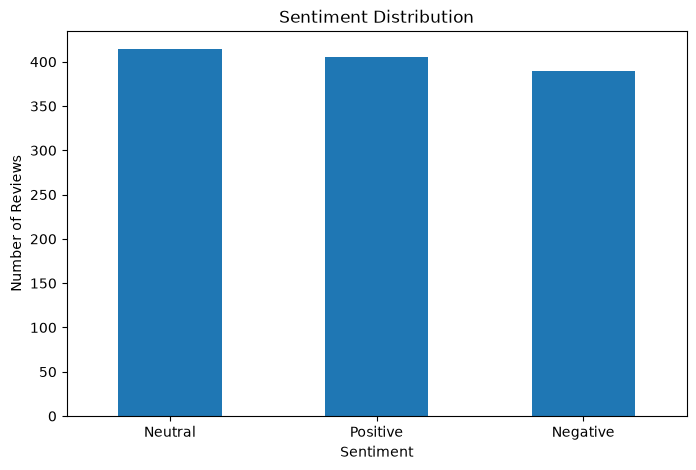

In [8]:
# Let's see how the reviews are distributed by sentiment

sentiment_counts = df["Sentiment_Label"].value_counts()

print(sentiment_counts)

sentiment_counts.plot(
    kind="bar",
    figsize=(8, 5),
    title="Sentiment Distribution"
)

plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

In [9]:
# Let's clean the review text

df["Clean_Review"] = (
    df["ReviewText"]
    .str.replace(r"Review #\d+:\s*", "", regex=True)
    .str.strip()
)

print(df[["ReviewText", "Clean_Review"]].head())

                                          ReviewText  \
0              Review #1: Highly disappointing read.   
1  Review #2: A page-turner with a powerful message.   
2          Review #3: A masterpiece of storytelling.   
3        Review #4: Heartwarming and inspiring read.   
4        Review #5: Neither good nor bad, just fine.   

                             Clean_Review  
0              Highly disappointing read.  
1  A page-turner with a powerful message.  
2          A masterpiece of storytelling.  
3        Heartwarming and inspiring read.  
4        Neither good nor bad, just fine.  


In [10]:
# Let's check how long the reviews are

df["Review_Length"] = df["Clean_Review"].str.len()

print(df["Review_Length"].describe())

count    1209.000000
mean       32.086022
std         6.611189
min        16.000000
25%        28.000000
50%        32.000000
75%        37.000000
max        45.000000
Name: Review_Length, dtype: float64


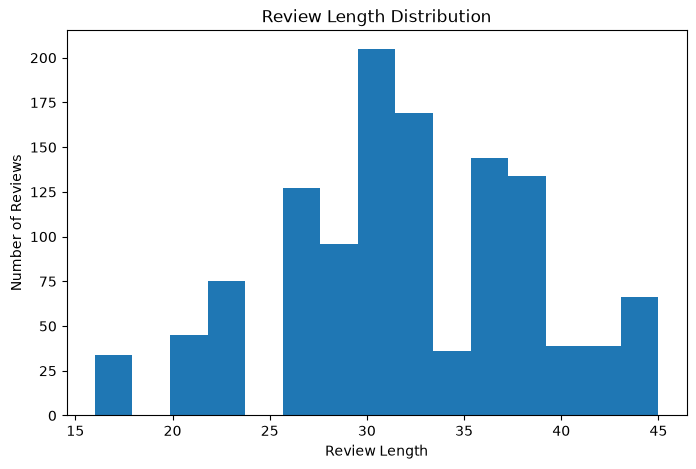

In [11]:
# Let's see how the review lengths are distributed

df["Review_Length"].plot(
    kind="hist",
    bins=15,
    figsize=(8, 5),
    title="Review Length Distribution"
)

plt.xlabel("Review Length")
plt.ylabel("Number of Reviews")
plt.show()

In [12]:
# Let's compare the average review length by sentiment

average_length = df.groupby("Sentiment_Label")["Review_Length"].mean()

print(average_length)

Sentiment_Label
Negative    26.871795
Neutral     35.239130
Positive    33.883951
Name: Review_Length, dtype: float64


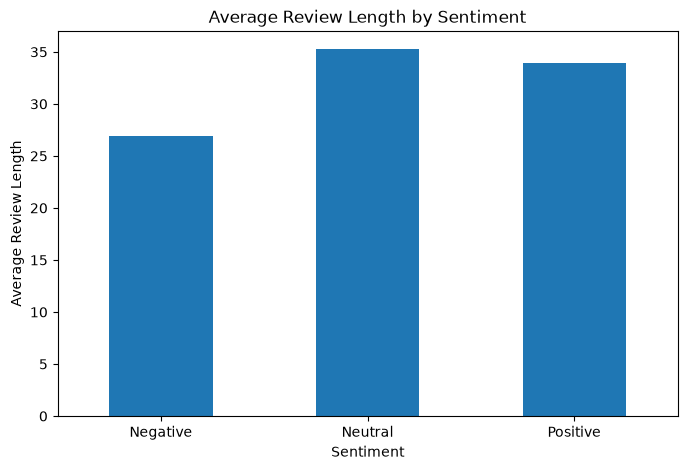

In [13]:
# Let's compare the average review length

average_length.plot(
    kind="bar",
    figsize=(8, 5),
    title="Average Review Length by Sentiment"
)

plt.xlabel("Sentiment")
plt.ylabel("Average Review Length")
plt.xticks(rotation=0)
plt.show()

In [14]:
# Let's see which words appear most often in the reviews

from collections import Counter
import re

words = []

for review in df["Clean_Review"]:
    review_words = re.findall(r"\b[a-zA-Z]+\b", review.lower())
    words.extend(review_words)

word_counts = Counter(words)

print(word_counts.most_common(15))

[('and', 295), ('a', 239), ('not', 181), ('read', 170), ('it', 134), ('plot', 123), ('bad', 97), ('to', 86), ('narrative', 83), ('too', 82), ('this', 80), ('book', 80), ('with', 78), ('couldn', 77), ('t', 77)]


In [15]:
# Let's remove common words that don't add much meaning

stop_words = {
    "a", "an", "the", "and", "or", "to", "of", "in", "is", "it",
    "this", "that", "with", "for", "on", "was", "were", "be",
    "as", "at", "by", "from", "but", "i", "my", "me", "very"
}

words = []

for review in df["Clean_Review"]:
    review_words = re.findall(r"\b[a-zA-Z]+\b", review.lower())

    for word in review_words:
        if word not in stop_words:
            words.append(word)

word_counts = Counter(words)

print(word_counts.most_common(15))

[('not', 181), ('read', 170), ('plot', 123), ('bad', 97), ('narrative', 83), ('too', 82), ('book', 80), ('couldn', 77), ('t', 77), ('writing', 73), ('story', 73), ('finish', 71), ('okay', 57), ('exciting', 57), ('heartwarming', 53)]


In [16]:
# Let's check the most common words for each type of review

for sentiment in ["Negative", "Neutral", "Positive"]:
    reviews = df[df["Sentiment_Label"] == sentiment]["Clean_Review"]

    words = []

    for review in reviews:
        review_words = re.findall(r"\b[a-zA-Z]+\b", review.lower())

        for word in review_words:
            if word not in stop_words:
                words.append(word)

    word_counts = Counter(words)

    print(f"\n{sentiment} reviews:")
    print(word_counts.most_common(10))


Negative reviews:
[('plot', 84), ('highly', 49), ('disappointing', 49), ('read', 49), ('overhyped', 49), ('underwhelming', 49), ('struggled', 47), ('stay', 47), ('interested', 47), ('confusing', 45)]

Neutral reviews:
[('not', 142), ('story', 73), ('okay', 57), ('too', 57), ('exciting', 57), ('neither', 52), ('good', 52), ('nor', 52), ('bad', 52), ('just', 52)]

Positive reviews:
[('read', 89), ('book', 80), ('heartwarming', 53), ('inspiring', 53), ('delightful', 51), ('captivating', 51), ('narrative', 51), ('couldn', 45), ('t', 45), ('put', 45)]


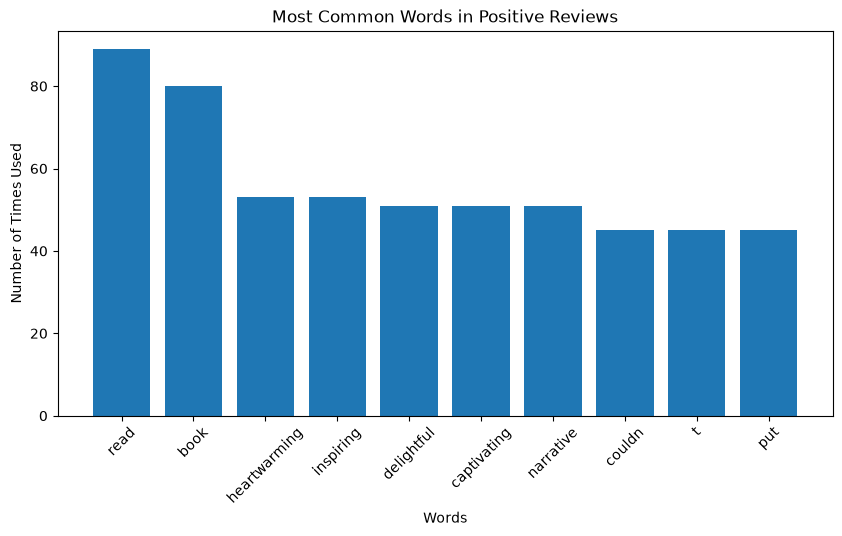

In [17]:
# Let's make a simple chart of the most common words

top_words = word_counts.most_common(10)

words = [word for word, count in top_words]
counts = [count for word, count in top_words]

plt.figure(figsize=(10, 5))

plt.bar(words, counts)

plt.title("Most Common Words in Positive Reviews")
plt.xlabel("Words")
plt.ylabel("Number of Times Used")

plt.xticks(rotation=45)
plt.show()

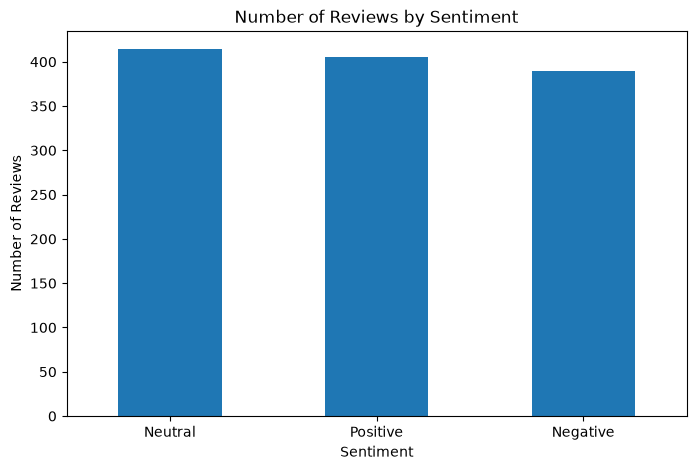

In [18]:
# Let's make a chart to compare the three sentiments

sentiment_counts = df["Sentiment_Label"].value_counts()

sentiment_counts.plot(
    kind="bar",
    figsize=(8, 5),
    title="Number of Reviews by Sentiment"
)

plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

Sentiment_Label
Negative    26.871795
Neutral     35.239130
Positive    33.883951
Name: Review_Length, dtype: float64


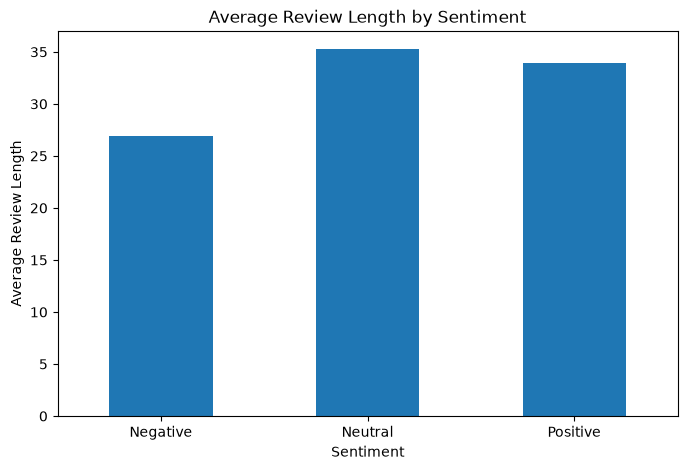

In [19]:
# Let's compare the average length of each type of review

average_length = df.groupby("Sentiment_Label")["Review_Length"].mean()

print(average_length)

average_length.plot(
    kind="bar",
    figsize=(8, 5),
    title="Average Review Length by Sentiment"
)

plt.xlabel("Sentiment")
plt.ylabel("Average Review Length")
plt.xticks(rotation=0)
plt.show()

In [20]:
# Let's calculate the percentage of each sentiment

sentiment_percentage = df["Sentiment_Label"].value_counts(normalize=True) * 100

print(sentiment_percentage.round(2))

Sentiment_Label
Neutral     34.24
Positive    33.50
Negative    32.26
Name: proportion, dtype: float64


In [21]:
## Key Findings

#- The dataset contains 1,209 book reviews.
#- Neutral reviews are the most common, making up 34.24% of the dataset.
#- Positive reviews make up 33.50% of the reviews.
#- Negative reviews make up 32.26% of the reviews.
#- Negative reviews are shorter on average, with an average length of about 26.87 characters.
#- Neutral reviews are the longest on average, with an average length of about 35.24 characters.
#- Negative reviews commonly include words such as "disappointing", "overhyped", "underwhelming", and "confusing".
#- Positive reviews commonly include words such as "heartwarming", "inspiring", "delightful", and "captivating".
#- Overall, the three sentiment categories are fairly balanced in the dataset.

In [22]:
## Task 4 Conclusion

#In this task, I analyzed a book review dataset using Python and explored the
#sentiment of different reviews. I cleaned the review text, analyzed common
#words, compared review lengths, and visualized the distribution of positive,
#negative, and neutral reviews.

#The results showed that the three sentiment categories are fairly balanced.
#The word analysis also helped identify the types of words commonly used in
#different sentiments.

#This task helped me understand how text data can be cleaned, analyzed, and
#visualized to find useful patterns in customer opinions.